In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import datetime
import io
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import requests
import seaborn as sns
import yfinance as yf

# Data Collection

In [3]:
STOCKS = ['AAPL', 'TSLA', 'MSFT']
current_date = str(datetime.date.today())
end_date = '2025-04-01'

NASDAQ_TICKER_URL = "https://www.nasdaqtrader.com/dynamic/SymDir/nasdaqlisted.txt"
NASDAQ_STOCKS = {}

OUTPUT_PATH = Path("/content/drive/MyDrive/Data Science projects/stock_market_prediction/outputs")

In [4]:
def get_nasdaq_tickers():
  response = requests.get(NASDAQ_TICKER_URL)
  df = pd.read_csv(io.StringIO(response.text), sep='|', skipfooter=1, engine='python')
  tickers_list = dict(zip(df['Symbol'].str.strip(), df['Security Name'].str.strip()))
  df.to_csv(OUTPUT_PATH / 'nasdaq_stocks_list.csv')
  return tickers_list

In [5]:
NASDAQ_STOCKS = get_nasdaq_tickers()

# print first 5 stocks from whole nasdaq list
dict(list(NASDAQ_STOCKS.items())[:5])

{'AACB': 'Artius II Acquisition Inc. - Class A Ordinary Shares',
 'AACBR': 'Artius II Acquisition Inc. - Rights',
 'AACBU': 'Artius II Acquisition Inc. - Units',
 'AACG': 'ATA Creativity Global - American Depositary Shares, each representing two common shares',
 'AADR': 'AdvisorShares Dorsey Wright ADR ETF'}

In [6]:
data = {}
for stock in STOCKS:
    try:
        df = yf.download(tickers=stock, period='max', end=end_date, interval='1d', auto_adjust=False, multi_level_index=False)
        data[stock] = df
    except Exception as e:
        print(f"Couldn't download the data for the {stock}: {e}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [7]:
os.makedirs(OUTPUT_PATH /"Dataset", exist_ok=True)

for stock in STOCKS:
    df = data[stock].copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df.loc[:end_date]
    df.to_csv(f'{OUTPUT_PATH}/Dataset/{stock}.csv', index=False)
    print(f'{stock}.csv saved')
    data[stock] = df

AAPL.csv saved
TSLA.csv saved
MSFT.csv saved


In [8]:
for stock in STOCKS:
    df = data[stock].copy()
    print('='*100)
    print(f'''{stock} ({NASDAQ_STOCKS[stock]})''')
    print('='*100)
    display(df.head())
    print(df.info())
    display(df.describe())

AAPL (Apple Inc. - Common Stock)


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1980-12-12,0.098389,0.128348,0.128906,0.128348,0.128348,469033600
1980-12-15,0.093256,0.121652,0.122210,0.121652,0.122210,175884800
1980-12-16,0.086412,0.112723,0.113281,0.112723,0.113281,105728000
1980-12-17,0.088550,0.115513,0.116071,0.115513,0.115513,86441600
1980-12-18,0.091118,0.118862,0.119420,0.118862,0.118862,73449600


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11165 entries, 1980-12-12 to 2025-03-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  11165 non-null  float64
 1   Close      11165 non-null  float64
 2   High       11165 non-null  float64
 3   Low        11165 non-null  float64
 4   Open       11165 non-null  float64
 5   Volume     11165 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 610.6 KB
None


,Adj Close,Close,High,Low,Open,Volume
count,11165.000000,11165.000000,11165.000000,11165.000000,11165.000000,1.116500e+04
mean,24.491363,25.432377,25.686170,25.153210,25.413142,3.140735e+08
std,51.611157,52.253850,52.759387,51.686722,52.202708,3.345346e+08
min,0.037645,0.049107,0.049665,0.049107,0.049665,0.000000e+00
25%,0.243472,0.301339,0.308036,0.294643,0.301339,1.099380e+08
50%,0.451843,0.552679,0.562500,0.542411,0.551071,2.024736e+08
75%,18.723713,22.057858,22.281429,21.812857,22.084999,3.945144e+08
max,257.853790,259.019989,260.100006,257.630005,258.190002,7.421641e+09


TSLA (Tesla, Inc.  - Common Stock)


...

,Adj Close,Close,High,Low,Open,Volume
count,3712.000000,3712.000000,3712.000000,3712.000000,3712.000000,3.712000e+03
mean,85.593532,85.593532,87.525357,83.593696,85.639700,9.668047e+07
std,111.682534,111.682534,114.317720,109.008365,111.813630,7.721812e+07
min,1.053333,1.053333,1.108667,0.998667,1.076000,1.777500e+06
25%,12.291667,12.291667,12.568000,12.066500,12.281167,4.958550e+07
50%,18.492333,18.492333,18.752000,18.206667,18.492000,8.243385e+07
75%,184.784996,184.784996,188.102501,180.630005,184.975002,1.222791e+08
max,479.859985,479.859985,488.540009,457.510010,475.899994,9.140820e+08


MSFT (Microsoft Corporation - Common Stock)


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1986-03-13,0.059389,0.097222,0.101563,0.088542,0.088542,1031788800
1986-03-14,0.061510,0.100694,0.102431,0.097222,0.097222,308160000
1986-03-17,0.062571,0.102431,0.103299,0.100694,0.100694,133171200
1986-03-18,0.060979,0.099826,0.103299,0.098958,0.102431,67766400
1986-03-19,0.059919,0.098090,0.100694,0.097222,0.099826,47894400


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9839 entries, 1986-03-13 to 2025-03-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  9839 non-null   float64
 1   Close      9839 non-null   float64
 2   High       9839 non-null   float64
 3   Low        9839 non-null   float64
 4   Open       9839 non-null   float64
 5   Volume     9839 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 538.1 KB
None


,Adj Close,Close,High,Low,Open,Volume
count,9839.000000,9839.000000,9839.000000,9839.000000,9839.000000,9.839000e+03
mean,58.369287,64.510376,65.147814,63.823727,64.496970,5.617711e+07
std,100.074990,100.713690,101.609628,99.721315,100.699110,3.810462e+07
min,0.055147,0.090278,0.092014,0.088542,0.088542,2.304000e+06
25%,3.634115,5.949219,6.042969,5.867188,5.953125,3.120620e+07
50%,19.176378,27.540001,27.830000,27.230000,27.500000,4.926240e+07
75%,40.305672,48.179375,48.789999,47.590000,48.078125,7.018905e+07
max,462.375580,467.559998,468.350006,464.459991,467.000000,1.031789e+09


In [9]:
df_adjclose = pd.DataFrame()
for stock in STOCKS:
    df_adjclose[stock] = data[stock]['Adj Close']

display(df_adjclose)

,AAPL,TSLA,MSFT
Date,,,
1980-12-12,0.098389,NaN,NaN
1980-12-15,0.093256,NaN,NaN
1980-12-16,0.086412,NaN,NaN
1980-12-17,0.088550,NaN,NaN
1980-12-18,0.091118,NaN,NaN
...,...,...,...
2025-03-25,222.987488,288.140015,393.052887
2025-03-26,220.775040,272.059998,387.890564
2025-03-27,223.087143,273.130005,388.497284


In [10]:
#Plot Adjusted closing price
def plot_adj_close(df_adjclose):
    fig = go.Figure()
    for column in df_adjclose.columns:
        fig.add_trace(go.Scatter(x=df_adjclose.index, y=df_adjclose[column], mode='lines', name=column))

    fig.update_layout(
        title='Adjusted closing prices of STOCKS',
        xaxis_title='Date',
        yaxis_title='Price (USD)',
        legend_title='Stocks',
        template='plotly_dark',
        hovermode='x unified'
    )
    fig.show()

plot_adj_close(df_adjclose)

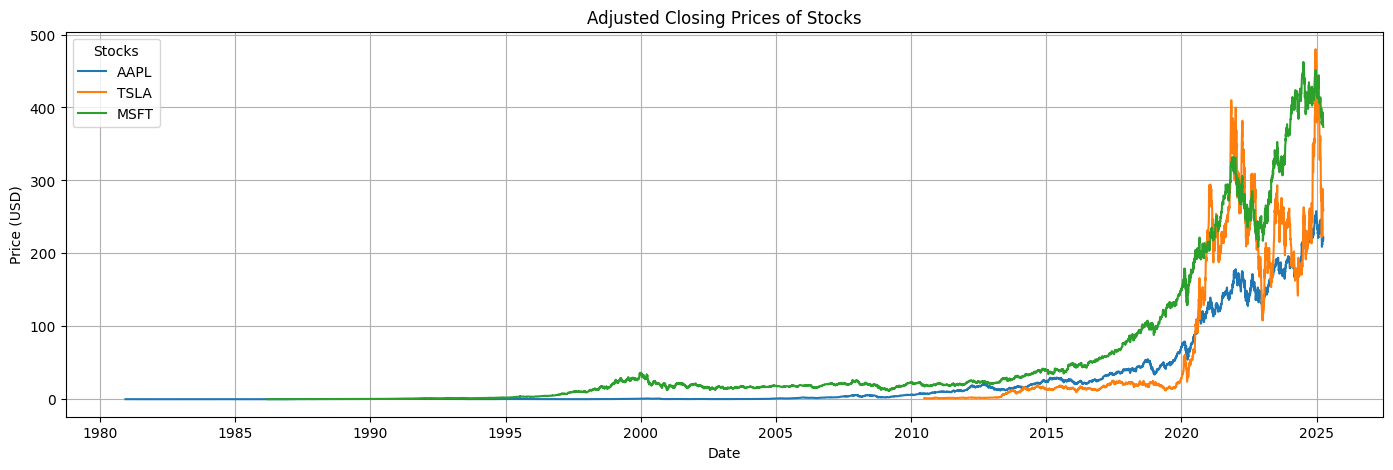

In [11]:
def plot_adj_close_matplotlib(df_adjclose):
    plt.figure(figsize=(17, 5))
    for column in df_adjclose.columns:
        plt.plot(df_adjclose.index, df_adjclose[column], label=column)

    plt.title('Adjusted Closing Prices of Stocks')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend(title='Stocks')
    plt.grid(True)
    plt.show()

plot_adj_close_matplotlib(df_adjclose)

In the plot, we can see that before Tesla's stock data appears (around 2010), Apple and Microsoft remained relatively steady. After 2010, all three STOCKS show an upward trend with increasing volatility. Since Tesla's earlier data is missing (NaN), I’ll drop the data before Tesla using dropna().

Droping the data before 2012 as data before this have not that much of change in it mostly steady till that point

In [12]:
df_adjclose = df_adjclose.dropna()

#Adding all the business day date range
full_index = pd.date_range(start=df_adjclose.index.min(), end=df_adjclose.index.max(), freq='B')
print('Original Trading dates:', len(df_adjclose))

#reindex and forward fill missing the prices
df_adjclose = df_adjclose.reindex(full_index).ffill()
print('Business days filled', len(df_adjclose))

Original Trading dates: 3712
Business days filled 3850


In [13]:
print(df_adjclose.isna().sum())

AAPL    0
TSLA    0
MSFT    0
dtype: int64


In [14]:
# Ploting the Adjusted closing price again after removing all the NaN values and getting all the dates of the business calender
plot_adj_close(df_adjclose)

From 2020 onwards, STOCKS like AAPL, TSLA, and MSFT show a sharp rise followed by increased volatility. Tesla and ASML in particular experienced rapid price swings, while Microsoft and Apple had a steadier upward trend. This period marks significant market movement, likely influenced by post-pandemic recovery and tech sector growth.

In [15]:
def plot_stock_analysis(stock_data, stock_name, ma_window=30):
    df = stock_data.copy()
    df.index = pd.to_datetime(df.index)
    df['Returns'] = df['Close'].pct_change()

    fig, axes = plt.subplots(1, 5, figsize=(25,4))
    axes = axes.flatten()

    # Line Plot
    axes[0].plot(df['Close'], label='Close Price')
    axes[0].set_title(f'{stock_name} - Close Price')
    axes[0].set_ylabel('Price')

    # Boxplot
    sns.boxplot(y=df['Close'], ax=axes[1])
    axes[1].set_title(f'{stock_name} - Price Distribution')

    # Histogram
    axes[2].hist(df['Close'], bins=30, edgecolor='black', alpha=0.7)
    axes[2].set_title(f'{stock_name} - Histogram of Close Prices')
    axes[2].set_xlabel('Price')
    axes[2].set_ylabel('Frequency')

    # Rolling Average
    axes[3].plot(df['Close'], label='Close Price')
    axes[3].plot(df['Close'].rolling(window=ma_window).mean(), label=f'{ma_window}-day MA', color='orange')
    axes[3].set_title(f'{stock_name} - Rolling Average')
    axes[3].legend()

    # Daily Returns
    axes[4].plot(df['Returns'], label='Daily Returns', color='green')
    axes[4].set_title(f'{stock_name} - Daily Returns')
    axes[4].set_ylabel('Returns')

    plt.suptitle(stock_name, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    return df['Returns']

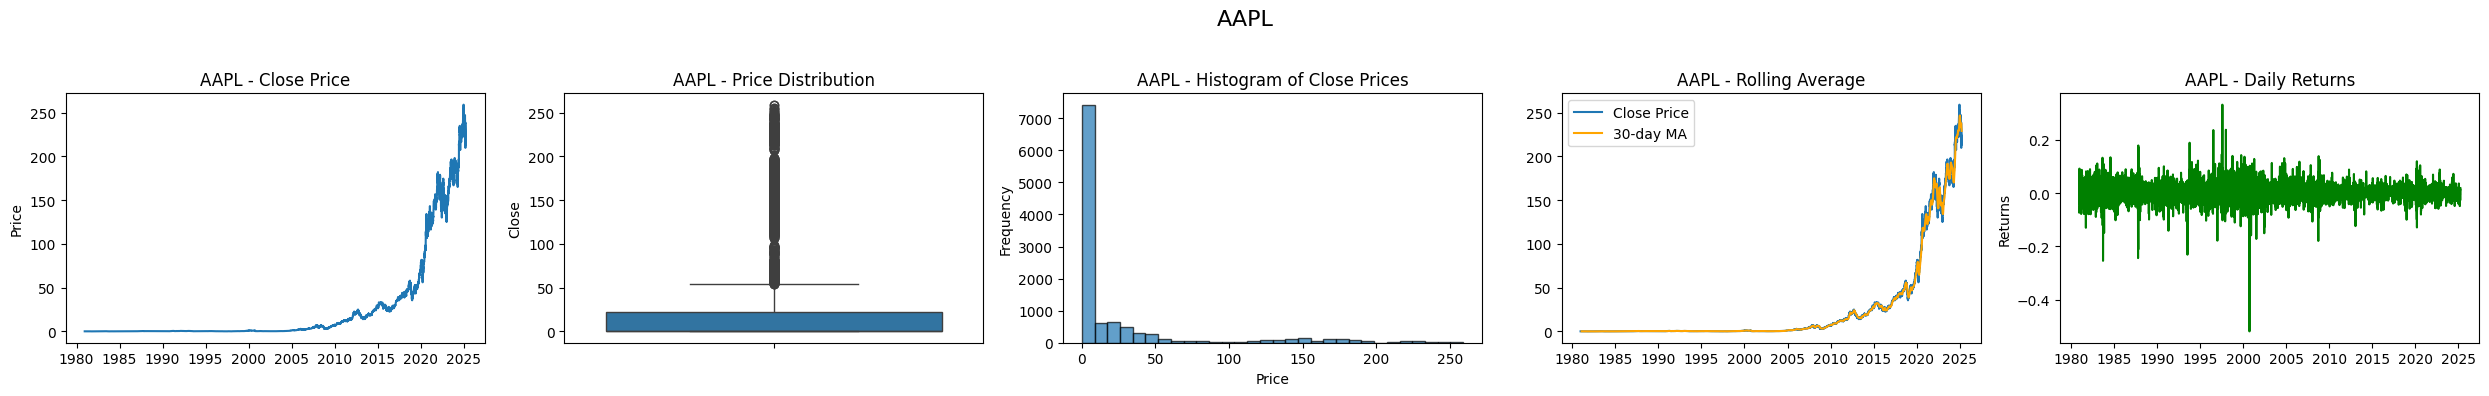

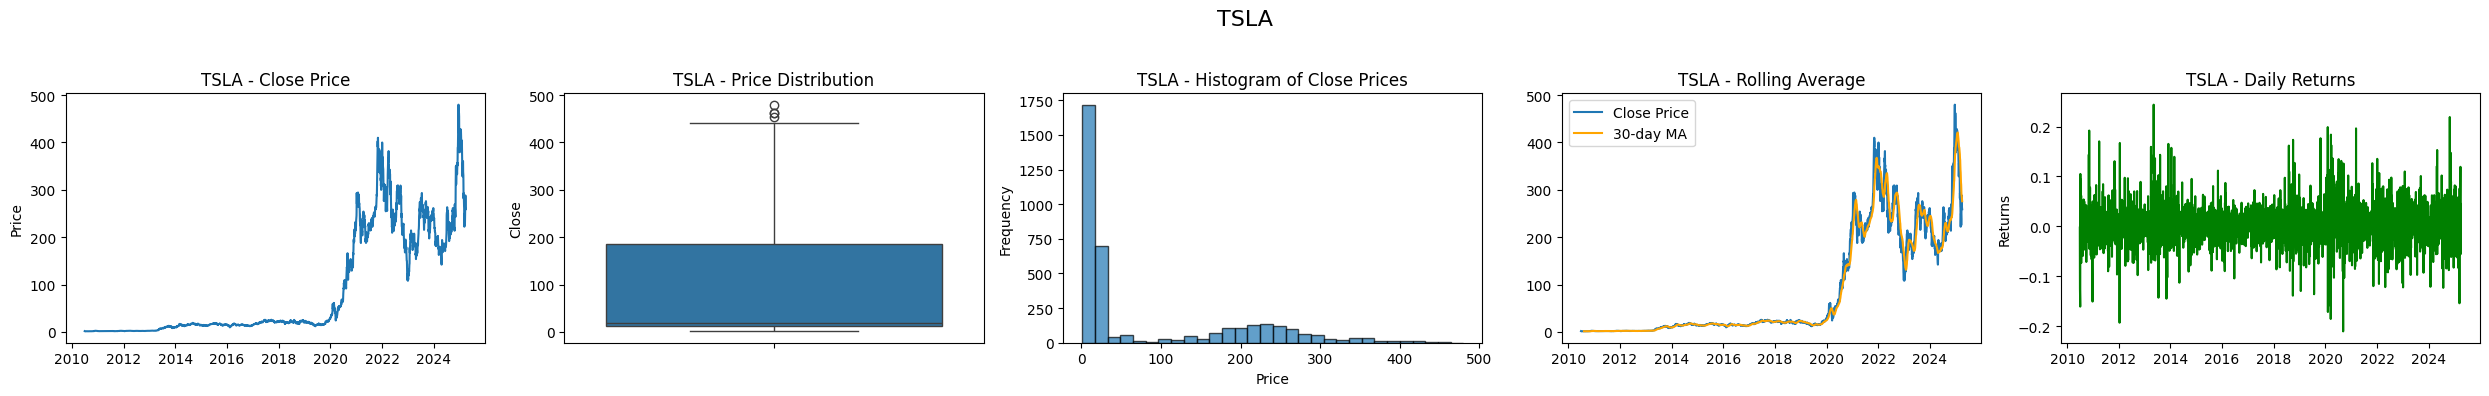

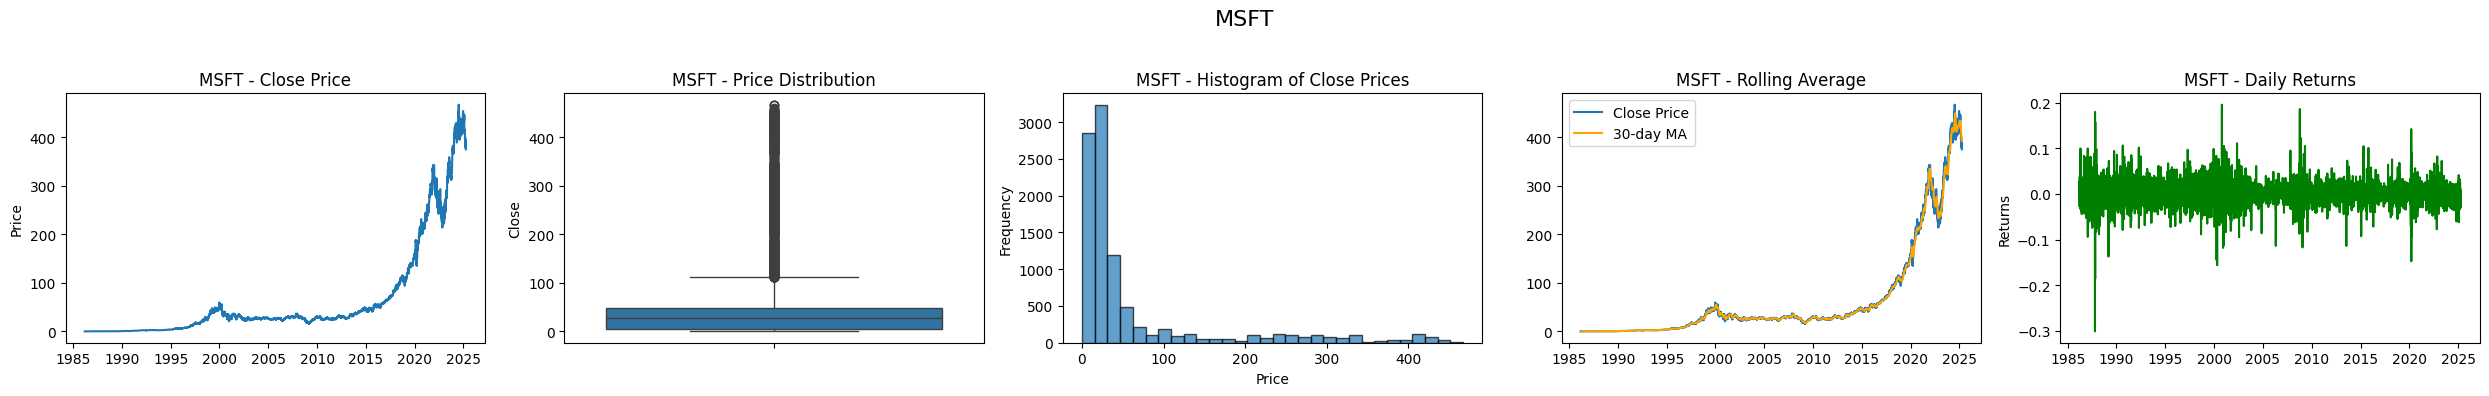

In [16]:
daily_returns_dict = {}

for stock in STOCKS:  # your list of tickers
    daily_returns_dict[stock] = plot_stock_analysis(data[stock], stock)

In [17]:
# Plotting open and close for the year 2022 to see the fluctuations
def plot_open_close(stock, df):
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df.index, y=df['Open'], mode='lines', name='Open'))
    fig.add_trace(go.Scatter(x=df.index, y=df['Close'], mode='lines', name='Close'))

    fig.update_layout(
        title=f'Open and Close Stock Prices Over Time for {stock}',
        xaxis_title='Date',
        yaxis_title='Price (USD)',
        legend_title='Price Type',
        template='plotly_dark',
        hovermode='x unified'
    )
    fig.show()

for stock in STOCKS:
    df_plot = data[stock].loc['2022'].copy()
    plot_open_close(stock, df_plot)

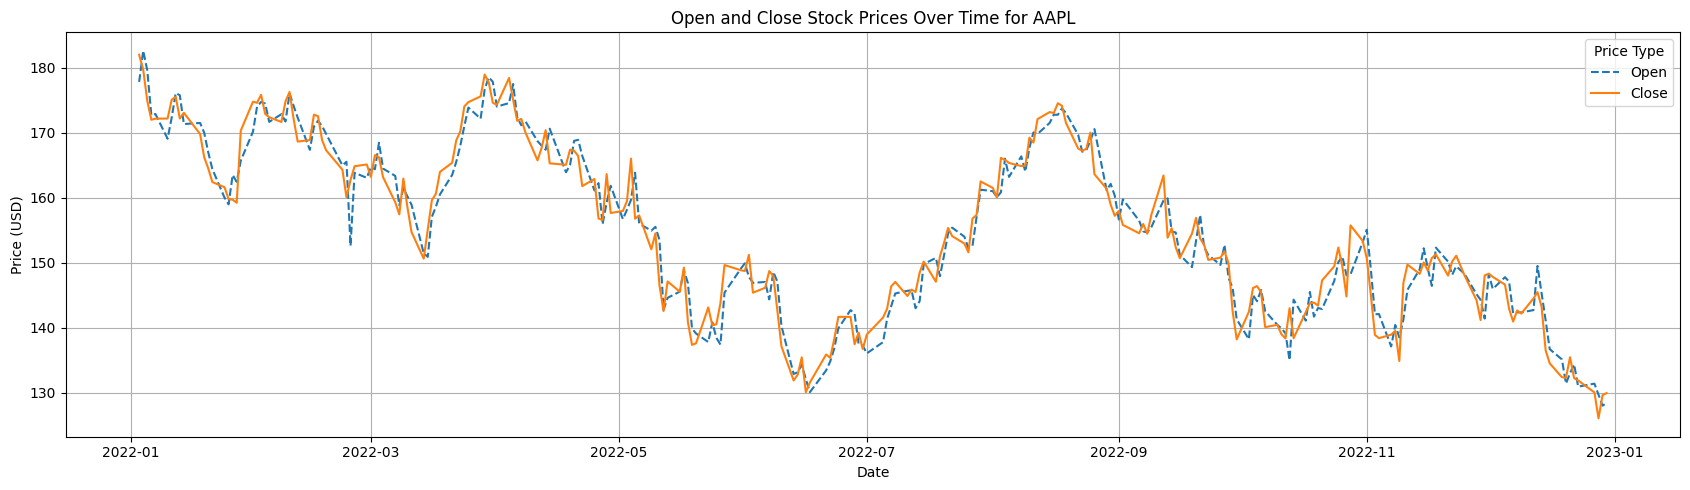

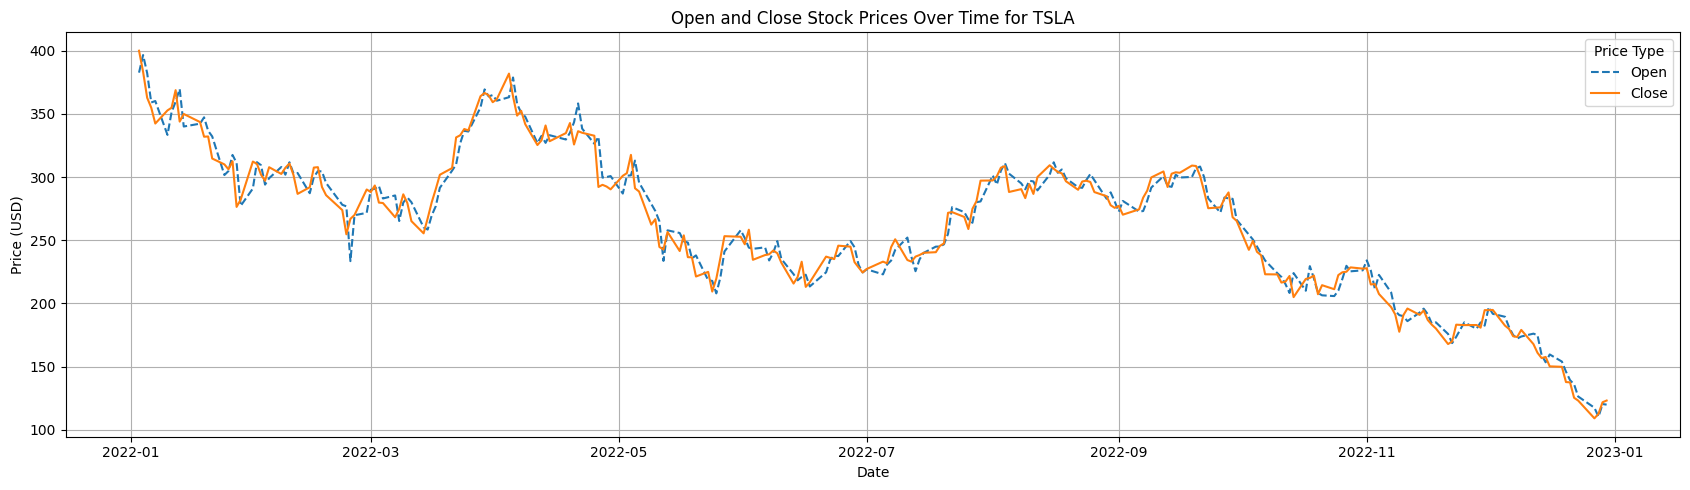

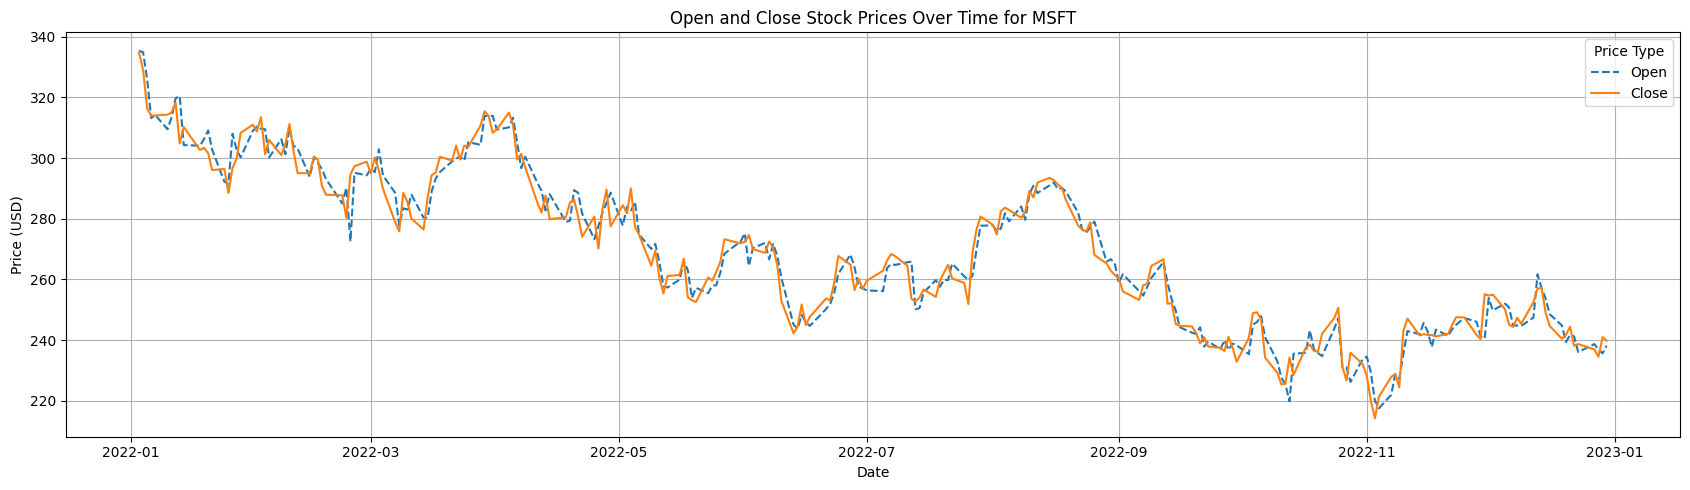

In [18]:
def plot_open_close_matplotlib(stock, df):
    plt.figure(figsize=(17, 5))
    plt.plot(df.index, df['Open'], label='Open', linestyle='--')
    plt.plot(df.index, df['Close'], label='Close', linestyle='-')
    plt.title(f'Open and Close Stock Prices Over Time for {stock}')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend(title='Price Type')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for stock in STOCKS:
    df_plot = data[stock].loc['2022'].copy()
    plot_open_close_matplotlib(stock, df_plot)

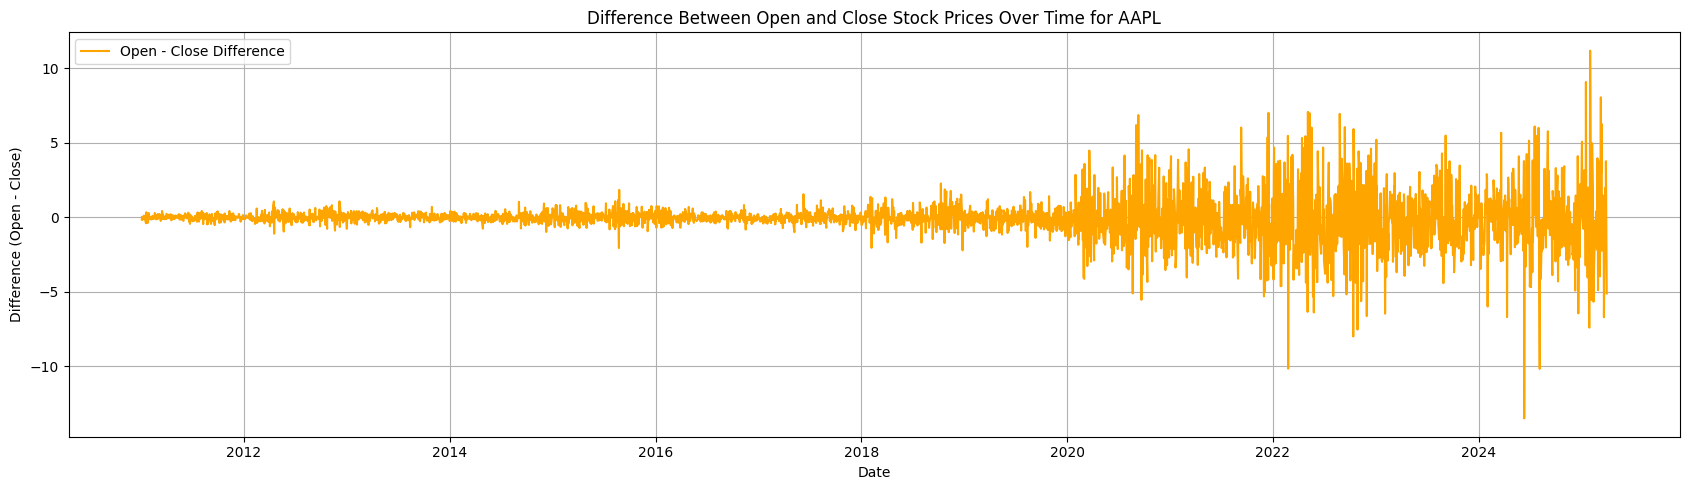

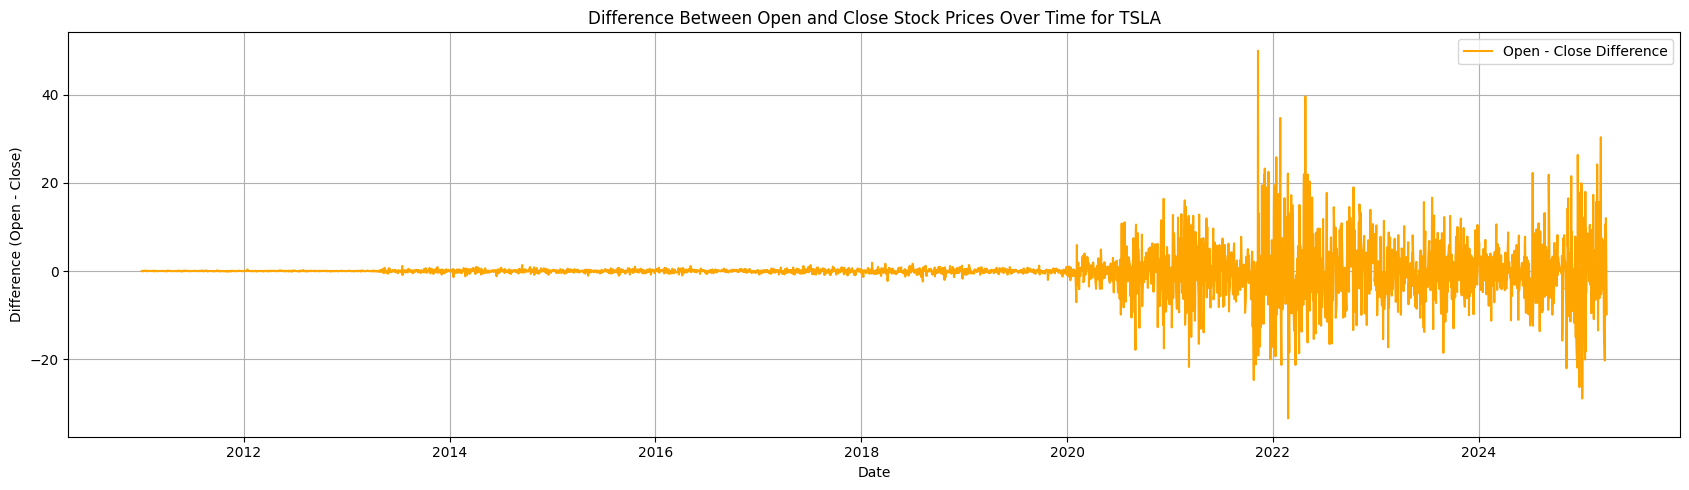

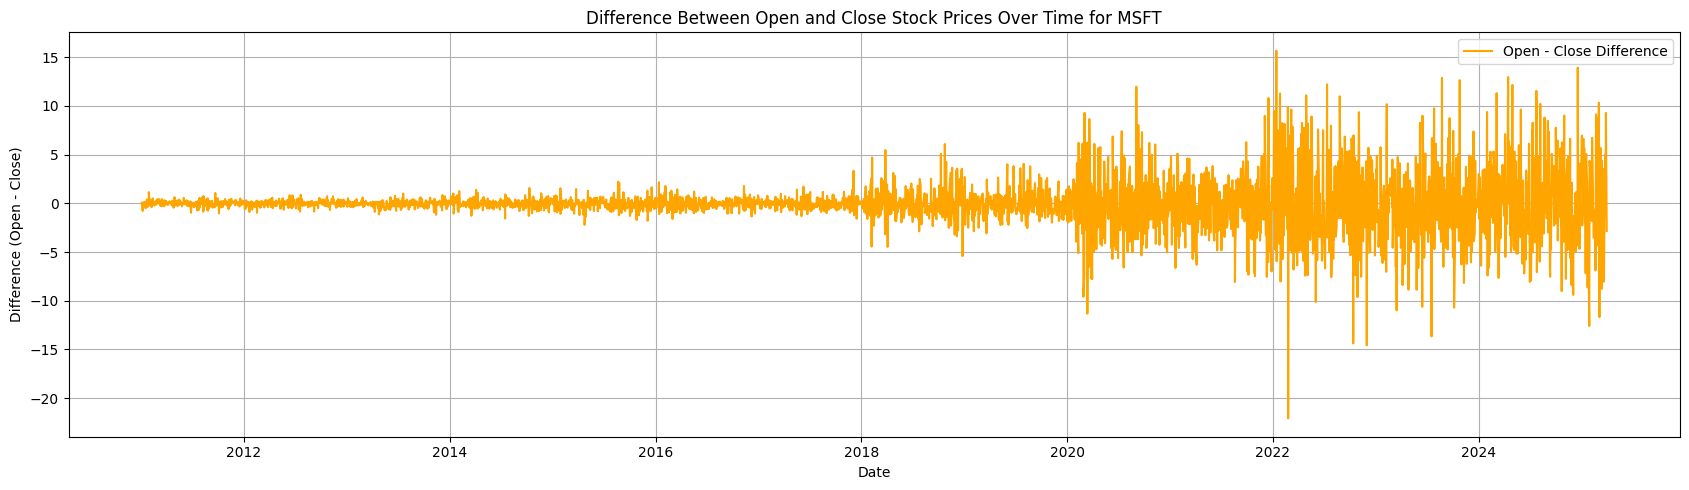

In [19]:
for stock in STOCKS:
    df_plot = data[stock].loc['2011':].copy()
    df_plot['difference'] = df_plot['Open'] - df_plot['Close']
    plt.figure(figsize=(17, 5))
    plt.plot(df_plot.index, df_plot['difference'], label='Open - Close Difference', color='orange')
    plt.title(f'Difference Between Open and Close Stock Prices Over Time for {stock}')
    plt.xlabel('Date')
    plt.ylabel('Difference (Open - Close)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

The difference between open and close prices stayed relatively small before 2020 for this STOCKS. After 2020, the fluctuations became more noticeable, especially for Tesla, which shows larger daily price swings. This suggests increased market activity and volatility in recent years.

In [20]:
# Candlestick Plots
for stock in STOCKS:
    df_plot = data[stock].loc['2022':'2022'].copy()
    fig_candle = go.Figure(data=[go.Candlestick(x=df_plot.index,
        open=df_plot['Open'],
        high=df_plot['High'],
        low=df_plot['Low'],
        close=df_plot['Close']
    )])
    fig_candle.update_layout(
        title=f'Candlestick Chart for {stock}',
        xaxis_title='Date',
        yaxis_title='Price (USD)',
        xaxis_rangeslider_visible=False
    )
    fig_candle.show()

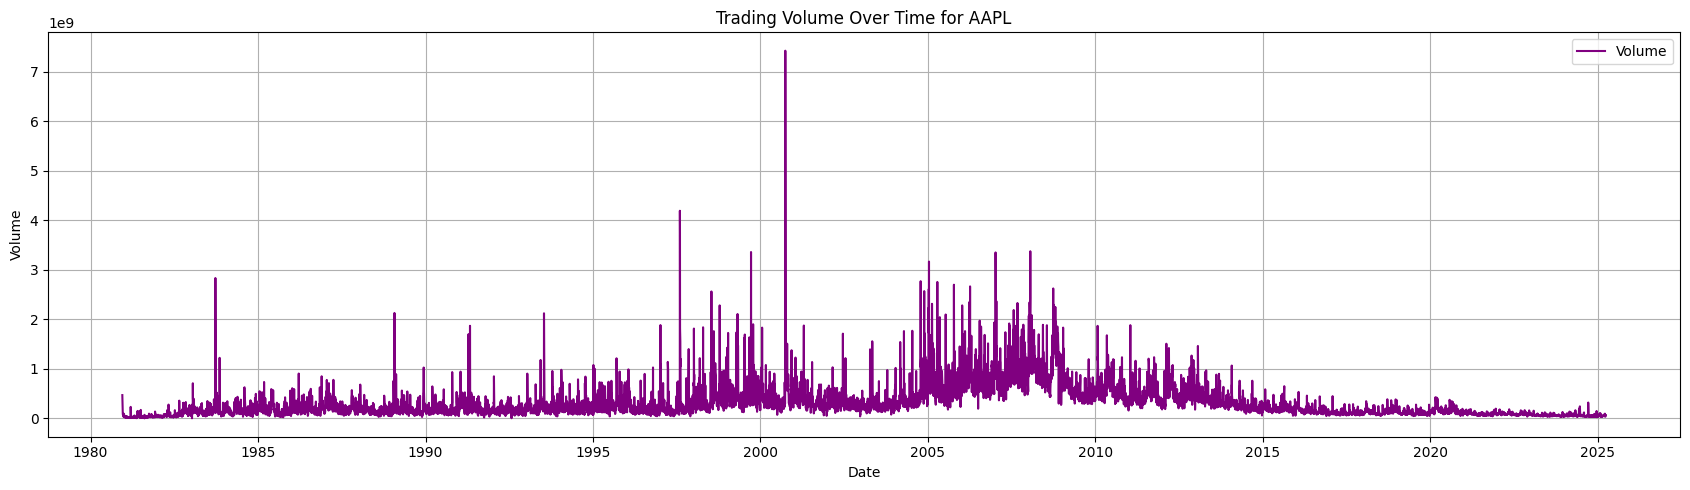

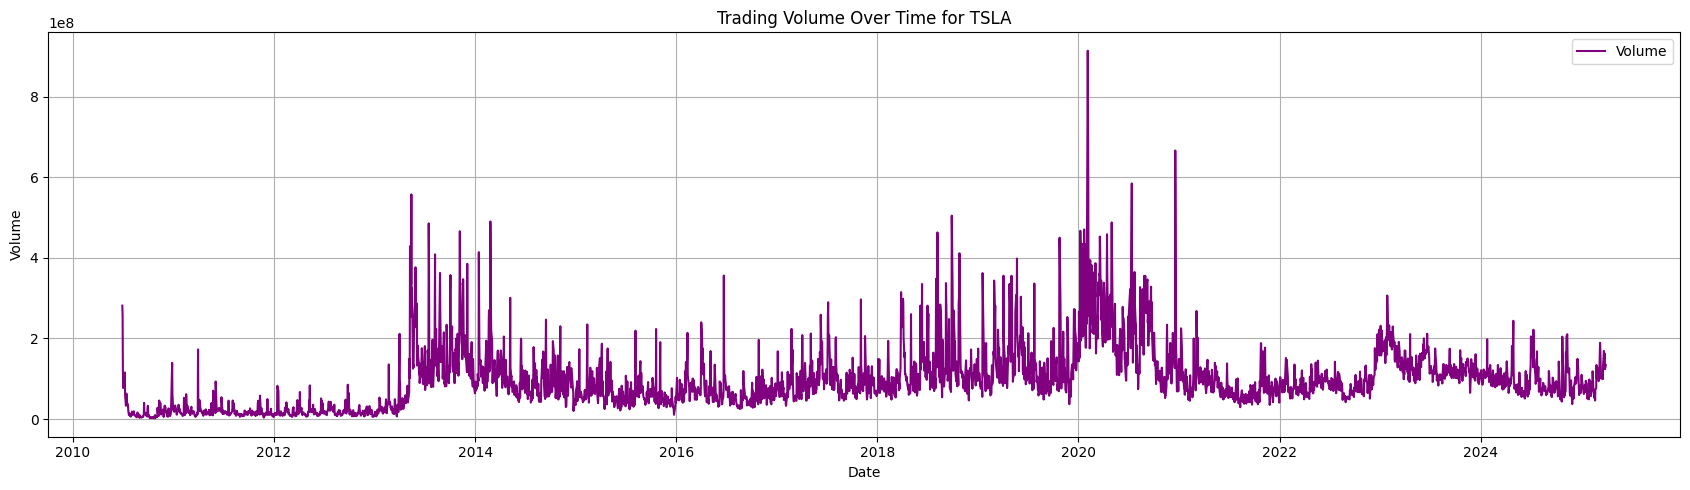

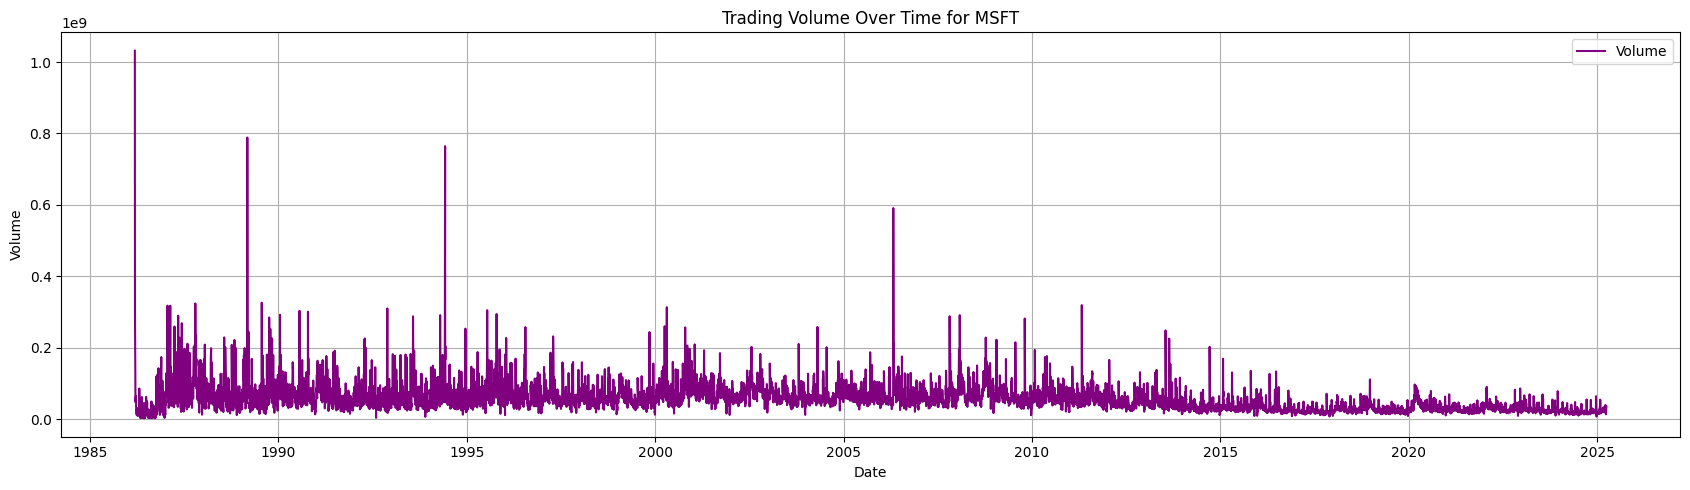

In [21]:
for stock in STOCKS:
    df_plot = data[stock].copy()
    plt.figure(figsize=(17, 5))
    plt.plot(df_plot.index, df_plot['Volume'], color='purple', label='Volume')
    plt.title(f'Trading Volume Over Time for {stock}')
    plt.xlabel('Date')
    plt.ylabel('Volume')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

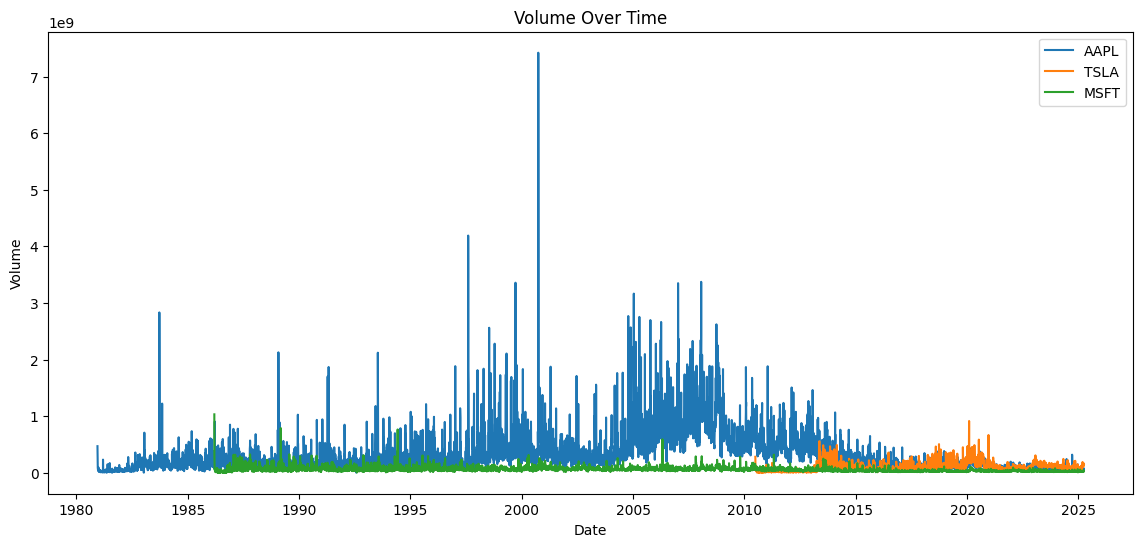

In [22]:
# Volume Spikes
plt.figure(figsize=(14, 6))
for stock in STOCKS:
    df = data[stock].copy()
    plt.plot(df.index, df['Volume'], label=stock)
plt.title('Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()

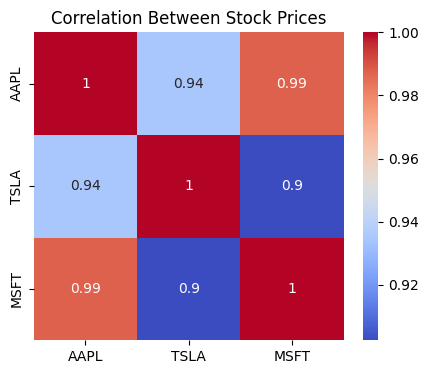

In [23]:
# Correlation heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(df_adjclose.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Stock Prices')
plt.show()

In [24]:
split_value = int(0.9*len(df_adjclose))

# Train-test split
train_data = df_adjclose[:split_value]
test_data = df_adjclose[split_value:]
print(train_data.shape, test_data.shape)

(3465, 3) (385, 3)


In [25]:
# Save data
joblib.dump(train_data, OUTPUT_PATH / 'train_data.joblib')
joblib.dump(test_data, OUTPUT_PATH / 'test_data.joblib')
df_adjclose.to_csv(OUTPUT_PATH /'adjclose_final_data.csv')